In [1]:
import torch
import requests
import torch.nn as nn
import torch.nn.functional as F
import os

### 获得 Input Embedding

In [2]:
if not os.path.exists('./example.txt'):
    url = 'https://huggingface.co/datasets/goendalf666/sales-textbook_for_convincing_and_selling/raw/main/sales_textbook.txt'
    response = requests.get(url)
    with open('./example.txt', 'w') as f:
        f.write(response.text)
with open('./example.txt', 'r') as f:
    text = f.read()
print(text[:1000])

Chapter 1: Building Rapport and Capturing Attention
Subpoint: Understanding the Importance of Building Rapport
Building rapport is a fundamental skill in sales that cannot be underestimated. It lays the foundation for establishing a connection with your potential customers, gaining their trust, and ultimately convincing them to make a purchase. Rapport can be defined as a harmonious relationship based on mutual understanding and empathy. When you build rapport with someone, you create a sense of familiarity, comfort, and shared interests, making it easier to communicate and influence their decision-making process.
One of the main reasons why building rapport is crucial in sales is that people are more likely to buy from someone they like and trust. By establishing a positive and genuine connection with your customers, you increase their confidence in you and your product or service. People want to do business with individuals they feel comfortable with, those who understand their needs

In [3]:
### hyperparameters
context_length = 16 ### 每句话只要16个token
d_model = 64
batch_size = 4 ### 一次性训练4句话 数据结构是(batch_size, context_length, d_model)



In [6]:
### 把document出现的所有字符进行编码，得到一个字符到数字的映射表
### 使用OpenAI tiktoken库进行编码
import tiktoken
encoding = tiktoken.get_encoding('cl100k_base')

tokenized_text = encoding.encode(text)
# print(len(tokenized_text),len(text))
# print(tokenized_text[:100])

### train/val/test split
train_index = int(0.9 * len(tokenized_text))
train_data = tokenized_text[:train_index]
val_data = tokenized_text[train_index:]
# print(len(train_data), len(val_data))

idxs = torch.randint(low=0, high = len(tokenized_text) - context_length, size=(batch_size,))

x_batch = torch.stack([torch.tensor(tokenized_text[idx:idx+context_length]) for idx in idxs])  ### (batch_size, context_length) 
y_batch = torch.stack([torch.tensor(tokenized_text[idx+1:idx+context_length+1]) for idx in idxs])  ### (batch_size, 
print(x_batch)
print(x_batch.shape)

tensor([[ 3296,  1701,  2867,   323, 64694,  4221,    11, 22126,   709,   555,
          6029,   323, 84610,    11,  6763, 15749],
        [30357, 10765,  1521, 17738,    11,   499,   649, 78076,  8641,   279,
          6130,  7119,  3339,   264, 12096,  5597],
        [14645,   690,  1520,   499,  4822,  8469,   315,   279, 16029,   323,
         10519,   264, 15022,  6964,   304,   279],
        [94100,   315, 63120,    12, 57022,  7278, 66044,   512,  1271,  9615,
         25555,   304,  6763,    11,   433,   374]])
torch.Size([4, 16])


In [5]:
### define input embedding table
tokenized_text = torch.LongTensor(tokenized_text)
max_token_value = tokenized_text.max().item()
input_embedding_lookup_table = nn.Embedding(num_embeddings=max_token_value+1, embedding_dim=d_model)
x_batch_embedding = input_embedding_lookup_table(x_batch) ### (batch_size, context_length, d_model)
y_batch_embedding = input_embedding_lookup_table(y_batch) ### (batch_size, context_length, d_model)
print(x_batch_embedding.shape, y_batch_embedding.shape) ### x_batch_embedding 就是 input embedding 

torch.Size([4, 16, 64]) torch.Size([4, 16, 64])


In [6]:
### get positional embedding
position_embedding = torch.zeros((context_length, d_model)) ### (context_length, d_model)
position = torch.arange(0, context_length).unsqueeze(1) ### (context_length, 1)

div_term = torch.exp(torch.arange(start=0, end=d_model, step=2) * (-torch.log(torch.tensor(10000.0)) / d_model)) ### (d_model/2,)

position_embedding[:, ::2] = torch.sin(position * div_term) ### (context_length, d_model/2)
position_embedding[:, 1::2] = torch.cos(position * div_term) ### (context


position_embedding_lookup_table = position_embedding.unsqueeze(0) ### (1, context_length, d_model)
position_embedding_lookup_table = position_embedding.repeat(batch_size, 1, 1) ### (batch_size, context_length, d_model)
print(position_embedding_lookup_table.shape)

torch.Size([4, 16, 64])


In [7]:
### add input embedding and positional embedding
x = x_batch_embedding + position_embedding_lookup_table ### (batch_size, context_length, d_model)
y = y_batch_embedding + position_embedding_lookup_table ### (batch_size, context_length, d_model)

import pandas as pd
import numpy as np
# print(x[0].shape)
for i in range(batch_size):
    print(f'sample {i}:')
    print(pd.DataFrame(x[i].detach().numpy(), columns=[f'dim_{j}' for j in range(d_model)]))
# print(pd.DataFrame(x[0].detach().numpy(), columns=[f'dim_{i}' for i in range(d_model)]))


sample 0:
       dim_0     dim_1     dim_2     dim_3     dim_4     dim_5     dim_6  \
0  -0.212874  1.923318 -1.057035  1.015104  0.507975  2.473150  0.197345   
1   1.160889  0.438336  0.995588 -0.351876  1.618647 -0.639020 -0.724305   
2   1.693235  0.057157 -1.437007  0.656800  1.346116  1.156109  0.837614   
3  -0.415506 -1.627839  2.423277 -2.139807 -0.395601 -0.270095  0.502972   
4   1.040428  0.305338 -0.766661 -1.134639  1.266499 -0.099275  1.246334   
5   0.341798  0.957571  0.340164 -1.247299 -0.746818  0.955814 -0.081671   
6  -0.192814  1.814424 -2.989206 -0.376768  0.852241 -1.251354  0.651760   
7   2.577715  0.807674 -0.111508 -0.365449 -0.390197 -1.173976 -1.328891   
8   3.114474 -0.722448  1.180819  0.782766 -2.582811 -1.094874 -0.430382   
9   2.050811 -0.253784 -0.567236 -1.363434 -1.823040  0.851569 -0.047804   
10  0.560688 -2.737232  2.337619 -0.089937 -1.060437  0.627303 -3.250054   
11 -2.005126  0.202032  1.330842 -0.743686 -1.549036 -0.576243 -1.023713   
12

## 多头注意力机制
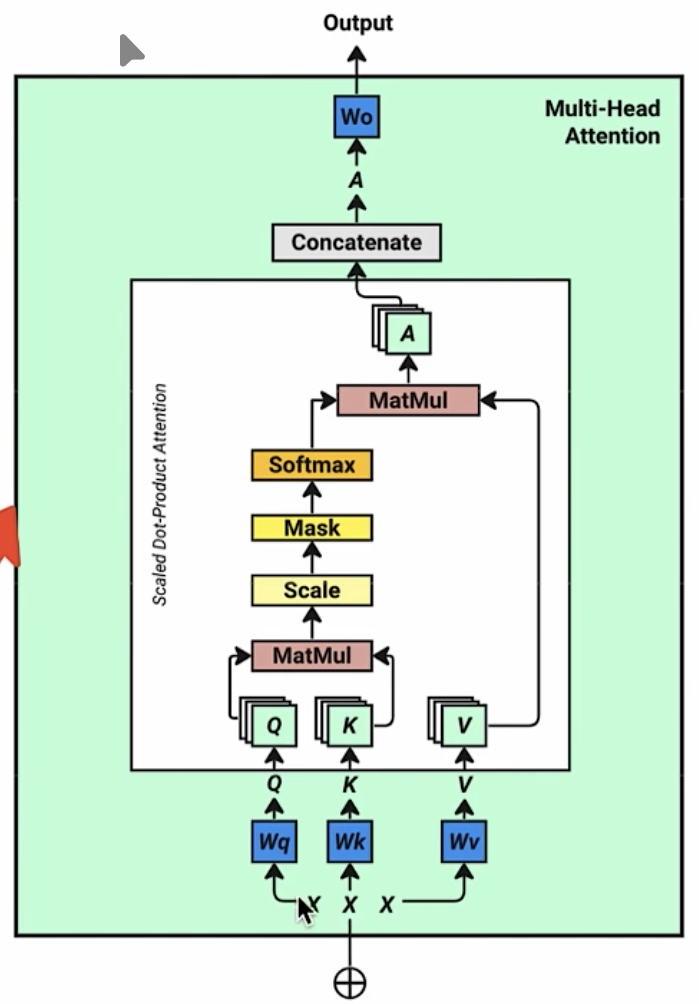

In [8]:
### get q, k ,v
W_q = nn.Linear(d_model, d_model)
W_k = nn.Linear(d_model, d_model)
W_v = nn.Linear(d_model, d_model)

Q = W_q(x) ### (batch_size, context_length, d_model)
K = W_k(x) ### (batch_size, context_length, d_model)
V = W_v(x) ### (batch_size, context_length, d_model)


In [9]:
### multi-head self attention
num_heads = 4
head_dim = d_model // num_heads
Q = Q.view(batch_size, context_length, num_heads, head_dim).transpose(1, 2) ### (batch_size, num_heads, context_length, head_dim)
K = K.view(batch_size, context_length, num_heads, head_dim).transpose(1, 2) ### (batch_size, num_heads, context_length, head_dim)
V = V.view(batch_size, context_length, num_heads, head_dim).transpose(1, 2) ### (batch_size, num_heads, context_length, head_dim)   
print(Q.shape, K.shape, V.shape)


torch.Size([4, 4, 16, 16]) torch.Size([4, 4, 16, 16]) torch.Size([4, 4, 16, 16])


In [ ]:
import math
# out = Q @ K.transpose(-2, -1) / math.sqrt(d_model // num_heads) ### (batch_size, num_heads, context_length, context_length)
out = Q @ K.permute(0, 1, 3, 2) / math.sqrt(d_model // num_heads) ### (batch_size, num_heads, context_length, context_length)



torch.Size([4, 4, 16, 16])


In [ ]:
### apply mask
mask = torch.tril(torch.ones((context_length, context_length))) 
mask = mask.unsqueeze(0).unsqueeze(0) 

mask = mask.repeat(batch_size, num_heads, 1, 1) 
out = out.masked_fill(mask == 0, float('-inf')) 

attention_scores = F.softmax(out, dim = -1)

A = attention_scores @ V

A = A.permute(0, 2, 1, 3).reshape(batch_size, context_length, d_model) 

tensor([[[[-0.5026, -0.3077,  0.8014,  ...,  0.1746, -0.2273,  0.5614],
          [ 0.2018, -0.4302,  0.7808,  ...,  0.1389, -0.2168, -0.0045],
          [ 0.1187, -0.0648,  0.6526,  ...,  0.1294, -0.3752,  0.2206],
          ...,
          [-0.4102,  0.2201,  0.6100,  ...,  0.1026,  0.0446,  0.0742],
          [-0.3853,  0.2164,  0.4723,  ...,  0.0590,  0.0899,  0.0778],
          [-0.3962,  0.2480,  0.4891,  ...,  0.0388,  0.1066,  0.0159]],

         [[ 0.0032,  0.4147,  0.9320,  ..., -0.0654,  0.3201, -0.2637],
          [ 0.3296,  0.4322,  0.9825,  ...,  0.3390,  0.9983, -0.1778],
          [ 0.6259,  0.3755,  0.8421,  ...,  0.0490,  0.8696, -0.3515],
          ...,
          [ 0.2665,  0.5661, -0.2055,  ...,  0.7050,  0.6382, -0.6385],
          [ 0.2213,  0.5867, -0.0786,  ...,  0.6261,  0.6818, -0.4701],
          [ 0.1270,  0.6139,  0.0190,  ...,  0.5358,  0.7961, -0.4983]],

         [[ 1.4121,  0.2979,  0.8162,  ...,  1.0042, -1.7182,  1.3495],
          [ 1.5850,  0.9829,  

In [ ]:
### Residual connection
out = A + x ### (batch_size, context_length, d_model)


In [43]:
### layer normalization
layer_norm = nn.LayerNorm(d_model)
out_layer = layer_norm(out) ### (batch_size, context_length, d_model)

FFN = nn.Sequential(
    nn.Linear(d_model, d_model*4),
    nn.ReLU(),
    nn.Linear(d_model*4, d_model)
)
output = FFN(out_layer) ### (batch_size, context_length, d_model)
### Residual connection
output = output + out_layer ### (batch_size, context_length, d_model)
output = layer_norm(output) ### (batch_size, context_length, d_model)

W_o = nn.Linear(d_model, max_token_value+1)
logits = W_o(output) ### (batch_size, context_length, vocab_size)
# print(logits[0,0])     
torch.argmax(logits[0,0]) ### 预测下一个token的id
encoding.decode([torch.argmax(logits[0,0]).item()]) ### 预测下一个token的字符

'total'